# Modules and Notebook Settings


In [1]:
%pwd

'/home/cecil/projects/ares/notebooks'

In [ ]:
import pandas as pd
import numpy as np
import warnings
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from ares.utils.common import load_json, save_json
from pathlib import Path

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

%matplotlib inline
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["figure.edgecolor"] = "black"
mpl.rcParams["axes.linewidth"] = 0.5

sns.set()
rc = {
    "font.family": ["serif"],
    "font.serif": "Times New Roman",
    "grid.color": "gainsboro",
    "grid.linestyle": "-",
}
sns.set_style(rc=rc)
sns.set_context("notebook", font_scale=0.8)

# Artefact Loading


In [ ]:
train_df = pd.read_csv("../artifacts/data/02-preprocessed/train_df.csv")
eval_df = pd.read_csv("../artifacts/data/02-preprocessed/eval_df.csv")
CACHE_PATH = Path("../artifacts/cache")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12460 entries, 0 to 12459
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   url                  12460 non-null  object 
 1   house_type           12460 non-null  object 
 2   bathrooms            12460 non-null  int64  
 3   bedrooms             12460 non-null  int64  
 4   price                12460 non-null  float64
 5   locality             12460 non-null  object 
 6   lat                  12460 non-null  float64
 7   lng                  12460 non-null  float64
 8   condition            12460 non-null  object 
 9   furnishing           12460 non-null  object 
 10  24_hour_electricity  12460 non-null  int64  
 11  air_conditioning     12460 non-null  int64  
 12  apartment            12460 non-null  int64  
 13  balcony              12460 non-null  int64  
 14  chandelier           12460 non-null  int64  
 15  dining_area          12460 non-null 

**The Key Rule:**

- Fit encoders/transformers on train only
- Appy the learned mappings to eval
- Cache mappings for faster inference

**Rational**
This prevents information of eval leaking into train to learn those patterns as well, by doing this, eval clearly remains unseen by the model. Hence it simulates real world performance.


# Price Features


In [220]:
train_df["log_price"] = np.log(train_df["price"])
eval_df["log_price"] = np.log(eval_df["price"])

# Locality Features


In [ ]:
def map_locality_class(df):
    """Maps locality to pre-defined residential classes

    Args:
        df (pd.DataFrame): Training dataset
    """
    locality_map = load_json(CACHE_PATH / "locality_class.json")
    df["locality_class"] = df["locality"].map(locality_map).fillna("Other")
    return df


def calculate_indices(train_df):
    """Calculate and assign price indices

    Args:
        df (pd.DataFrame): Training dataset
    """
    class_means = train_df.groupby("locality_class")["price"].mean()
    class_price_index = class_means.to_dict()
    save_json(CACHE_PATH / "class_price_index.json", class_price_index)

    locality_means = train_df.groupby("locality")["price"].mean()
    locality_price_index = locality_means.to_dict()
    save_json(CACHE_PATH / "locality_price_index.json", locality_price_index)
    
    class_std = train_df.groupby('loc_class')['price'].std()
    class_std = class_std.to_dict()


def build_locality_caches(train_df):
    """Build the cache on the training set

    Args:
        train_df (_type_): _description_
    """
    train_df = map_locality_class(train_df)
    calculate_indices(train_df)


ELITE_AREAS = {
    "Airport Residential Area",
    "Cantonments",
    "Ridge",
    "Roman Ridge",
    "Labone",
}


def get_global_references(df):
    """Calculates baseline statistics for the entire dataset."""
    return {
        "median": df["log_price"].median(),
        "std": df["log_price"].std(),
        "q25": df["log_price"].quantile(0.25),
        "q75": df["log_price"].quantile(0.75),
    }


def aggregate_neighborhoods(df):
    """Groups data by locality and calculates raw stats."""
    return (
        df.groupby("locality")["log_price"]
        .agg(
            n_listings="size",
            median_log="median",
            std_log="std",
            q25_log=lambda x: x.quantile(0.25),
            q75_log=lambda x: x.quantile(0.75),
        )
        .reset_index()
    )


def calculate_trust_weight(name, n, K):
    """Determines the smoothing weight (w) based on sample size and elite status."""
    if name in ELITE_AREAS:
        return 1.0
    return n / (n + K)


def get_tier_info(w):
    """Maps trust score to categorical tiers."""
    if w >= 0.75:
        return "A", 3
    if w >= 0.50:
        return "B", 2
    if w >= 0.25:
        return "C", 1
    return "D", 0


def compute_smoothed_stats(row, global_ref, K):
    """Applies Bayesian smoothing to a single neighborhood's stats."""
    w = calculate_trust_weight(row["locality"], row["n_listings"], K)
    tier_label, tier_code = get_tier_info(w)

    local_std = row["std_log"] if pd.notnull(row["std_log"]) else global_ref["std"]

    return {
        "loc_med_log": w * row["median_log"] + (1 - w) * global_ref["median"],
        "loc_q25_log": w * row["q25_log"] + (1 - w) * global_ref["q25"],
        "loc_q75_log": w * row["q75_log"] + (1 - w) * global_ref["q75"],
        "loc_std_dev": w * local_std + (1 - w) * global_ref["std"],
        "loc_trust_score": w,
        "loc_tier_code": tier_code,
        "loc_tier_label": tier_label,
    }


def get_stats(train_df, K=50):
    """Main Orchestrator: generates the stats_map and global_ref."""
    global_ref = get_global_references(train_df)
    neighborhood_df = aggregate_neighborhoods(train_df)

    stats_map = {
        row["locality"]: compute_smoothed_stats(row, global_ref, K)
        for _, row in neighborhood_df.iterrows()
    }

    return stats_map, global_ref

In [222]:
# Calculate the mean price for each residential class
class_means = train_df.groupby("residential_class")["price"].mean()

# Map these means back to the dataframe
train_df["class_price_index"] = train_df["residential_class"].map(class_means)
locality_means = train_df.groupby("locality")["price"].mean()
train_df["locality_price_index"] = train_df["locality"].map(locality_means)

In [ ]:
stats_map, global_ref = get_stats(train_df)

# House Features


In [225]:
train_df.condition.unique()

array(['New', 'Used', 'Renovated'], dtype=object)

In [226]:
condition_map = {
    "Used": 1,
    "Renovated": 2,
    "New": 3,
}
train_df["house_condition_coded"] = train_df["condition"].map(condition_map)


# Amenioty


In [ ]:
# Amenity group definitions (DO NOT CHANGE casually)

LUXURY_AMENITIES = [
    "air_conditioning",
    "chandelier",
    "microwave",
    "dishwasher",
    "refrigerator",
    "tv",
    "wi_fi",
    "hot_water",
    "dining_area",
]

BASELINE_AMENITIES = [
    "tiled_floor",
    "wardrobe",
    "kitchen_cabinets",
    "kitchen_shelf",
    "balcony",
    "apartment",
]

INFRA_AMENITIES = [
    "24_hour_electricity",
    "pre_paid_meter",
    "pop_ceiling",
]


In [ ]:
import pandas as pd


def build_amenity_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Core aggregates
    df["luxury_score"] = df[LUXURY_AMENITIES].sum(axis=1)
    df["baseline_score"] = df[BASELINE_AMENITIES].sum(axis=1)
    df["infra_score"] = df[INFRA_AMENITIES].sum(axis=1)

    # Regularizer
    df["amenity_count"] = df["luxury_score"] + df["baseline_score"] + df["infra_score"]

    return df


train_df = build_amenity_features(train_df)


In [230]:
Mapping = {
    # shared
    "Room & Parlour": "shared",
    "Bedsitter": "shared",
    "Shared Apartment": "shared",
    # multi-unit
    "Apartment": "multi_unit",
    "Studio Apartment": "multi_unit",
    "Mini Flat": "multi_unit",
    "Block of Flats": "multi_unit",
    "Condo": "multi_unit",
    "Maisonette": "multi_unit",
    "Penthouse": "multi_unit",
    # single-unit
    "House": "single_unit",
    "Duplex": "single_unit",
    "Bungalow": "single_unit",
    "Mansion": "single_unit",
    "Farm House": "single_unit",
    "Villa": "single_unit",
    "Chalet": "single_unit",
    "Townhouse / Terrace": "single_unit",
    "Townhouse/Terrace": "single_unit",
    "Townhouse": "single_unit",
}

train_df["unit_density"] = train_df["house_type"].map(Mapping)

train_df["is_luxury"] = train_df["house_type"].isin(["Penthouse", "Mansion", "Villa"])

# House Type
# 1. Convert the column to the 'category' dtype
train_df["house_type"] = train_df["house_type"].astype("category")
train_df["unit_density"] = train_df["unit_density"].astype("category")

In [232]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


def calculate_vif(df, target_col=None):
    """
    Calculate Variance Inflation Factor (VIF) for each numeric column in df.
    """
    # Keep only numeric columns
    numeric_df = df.select_dtypes(include=["float64", "int64"]).copy()

    # Drop target if provided
    if target_col and target_col in numeric_df.columns:
        numeric_df = numeric_df.drop(columns=[target_col])

    # Add constant for statsmodels
    X = add_constant(numeric_df)

    # Compute VIF (skip the first column = constant)
    vif_data = pd.DataFrame()
    vif_data["feature"] = numeric_df.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i + 1)  # skip constant at index 0
        for i in range(len(numeric_df.columns))
    ]

    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)


# Look at VIF and correlation with original training dataset
# df = pd.read_csv("/Users/riadanas/Desktop/housing regression MLE/data/raw/train.csv")
vif_table = calculate_vif(train_df, target_col="price")
print(vif_table)


                  feature         VIF
0                      tv         inf
1           kitchen_shelf         inf
2             infra_score         inf
3          baseline_score         inf
4            luxury_score         inf
5                   wi_fi         inf
6                wardrobe         inf
7             tiled_floor         inf
8            refrigerator         inf
9          pre_paid_meter         inf
10            pop_ceiling         inf
11              microwave         inf
12          amenity_count         inf
13       kitchen_cabinets         inf
14             dishwasher         inf
15            dining_area         inf
16             chandelier         inf
17    24_hour_electricity         inf
18                balcony         inf
19              apartment         inf
20       air_conditioning         inf
21              hot_water         inf
22            loc_med_log  139.221502
23            loc_q25_log  104.374283
24            loc_q75_log   83.614357
25   localit

In [233]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


def clean_multicollinearity(df, target_col="log_price"):
    """
    Remove multicollinear features systematically
    """
    print("=" * 60)
    print("CLEANING MULTICOLLINEARITY")
    print("=" * 60)

    # Step 1: Drop all individual amenity columns (keep engineered scores)
    amenity_cols = [
        "tv",
        "kitchen_shelf",
        "wi_fi",
        "wardrobe",
        "tiled_floor",
        "refrigerator",
        "pre_paid_meter",
        "pop_ceiling",
        "microwave",
        "kitchen_cabinets",
        "dishwasher",
        "dining_area",
        "chandelier",
        "24_hour_electricity",
        "balcony",
        "apartment",
        "air_conditioning",
        "hot_water",
    ]

    print(f"\n1. Dropping {len(amenity_cols)} individual amenity columns...")
    df_clean = df.drop(columns=[col for col in amenity_cols if col in df.columns])

    # Step 2: Among amenity scores, keep only the best one
    amenity_scores = ["amenity_count", "infra_score", "baseline_score", "luxury_score"]
    available_scores = [col for col in amenity_scores if col in df_clean.columns]

    if len(available_scores) > 1 and target_col in df.columns:
        print(f"\n2. Finding best amenity score from: {available_scores}")
        correlations = {}
        for col in available_scores:
            correlations[col] = abs(df_clean[col].corr(df_clean[target_col]))
            print(f"   {col}: {correlations[col]:.4f}")

        best_score = max(correlations, key=correlations.get)
        scores_to_drop = [col for col in available_scores if col != best_score]
        print(f"   → Keeping: {best_score}")
        print(f"   → Dropping: {scores_to_drop}")
        df_clean = df_clean.drop(columns=scores_to_drop)

    # Step 3: Drop redundant location percentile features
    location_percentiles = ["loc_med_log", "loc_q25_log", "loc_q75_log"]
    print(f"\n3. Dropping location percentiles: {location_percentiles}")
    df_clean = df_clean.drop(
        columns=[col for col in location_percentiles if col in df_clean.columns]
    )

    # Step 4: Check remaining VIF
    print(f"\n4. Calculating VIF on remaining features...")
    vif_result = calculate_vif(df_clean, target_col=target_col)

    print(f"\nFeatures remaining: {df_clean.shape[1]}")
    print(f"Rows: {df_clean.shape[0]}")

    return df_clean, vif_result


# Apply cleaning
train_df, vif_cleaned = clean_multicollinearity(train_df, target_col="price")

print("\n" + "=" * 60)
print("VIF AFTER CLEANING")
print("=" * 60)
print(vif_cleaned)


CLEANING MULTICOLLINEARITY

1. Dropping 18 individual amenity columns...

2. Finding best amenity score from: ['amenity_count', 'infra_score', 'baseline_score', 'luxury_score']
   amenity_count: 0.2230
   infra_score: 0.0008
   baseline_score: 0.1283
   luxury_score: 0.3260
   → Keeping: luxury_score
   → Dropping: ['amenity_count', 'infra_score', 'baseline_score']

3. Dropping location percentiles: ['loc_med_log', 'loc_q25_log', 'loc_q75_log']

4. Calculating VIF on remaining features...

Features remaining: 22
Rows: 12460

VIF AFTER CLEANING
                  feature        VIF
0         loc_trust_score  10.667150
1           loc_tier_code   9.454852
2               bathrooms   6.763355
3                bedrooms   6.580790
4    locality_price_index   5.225075
5               log_price   3.797915
6       class_price_index   3.527930
7                     lat   1.622648
8                     lng   1.569441
9            luxury_score   1.409962
10            loc_std_dev   1.143125
11  ho

In [236]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr


def comprehensive_feature_importance(df, target_col="log_price"):
    """
    Multiple methods to assess feature importance
    """
    # Prepare data
    feature_cols = [col for col in df.columns if col != target_col]
    X = df[feature_cols].select_dtypes(include=[np.number])
    y = df[target_col]

    # Remove any remaining NaN/inf
    X = X.replace([np.inf, -np.inf], np.nan)
    mask = ~(X.isna().any(axis=1) | y.isna())
    X = X[mask]
    y = y[mask]

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    results = {}

    # Method 1: Correlation with target
    print("=" * 60)
    print("METHOD 1: CORRELATION WITH PRICE")
    print("=" * 60)
    correlations = {}
    for col in X.columns:
        corr, pval = pearsonr(X[col], y)
        correlations[col] = {
            "correlation": corr,
            "abs_correlation": abs(corr),
            "p_value": pval,
        }

    corr_df = pd.DataFrame(correlations).T.sort_values(
        "abs_correlation", ascending=False
    )
    print(corr_df.head(15))
    results["correlation"] = corr_df

    # Method 2: Random Forest Feature Importance
    print("\n" + "=" * 60)
    print("METHOD 2: RANDOM FOREST IMPORTANCE")
    print("=" * 60)
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)

    rf_importance = pd.DataFrame(
        {"feature": X.columns, "importance": rf.feature_importances_}
    ).sort_values("importance", ascending=False)
    print(rf_importance.head(15))
    results["random_forest"] = rf_importance

    # Method 3: Permutation Importance
    print("\n" + "=" * 60)
    print("METHOD 3: PERMUTATION IMPORTANCE (more reliable)")
    print("=" * 60)
    perm_importance = permutation_importance(
        rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
    )

    perm_df = pd.DataFrame(
        {
            "feature": X.columns,
            "importance": perm_importance.importances_mean,
            "std": perm_importance.importances_std,
        }
    ).sort_values("importance", ascending=False)
    print(perm_df.head(15))
    results["permutation"] = perm_df

    # Method 4: Combined Score
    print("\n" + "=" * 60)
    print("METHOD 4: COMBINED IMPORTANCE SCORE")
    print("=" * 60)

    # Normalize each method to 0-1
    corr_norm = corr_df["abs_correlation"] / corr_df["abs_correlation"].max()
    rf_norm = (
        rf_importance.set_index("feature")["importance"]
        / rf_importance["importance"].max()
    )
    perm_norm = perm_df.set_index("feature")["importance"] / perm_df["importance"].max()

    combined = pd.DataFrame(
        {"correlation_score": corr_norm, "rf_score": rf_norm, "perm_score": perm_norm}
    )
    combined["combined_score"] = (
        combined["correlation_score"] * 0.3
        + combined["rf_score"] * 0.3
        + combined["perm_score"] * 0.4
    )
    combined = combined.sort_values("combined_score", ascending=False)
    print(combined.head(15))
    results["combined"] = combined

    return results, rf


# Run feature importance analysis
importance_results, model = comprehensive_feature_importance(
    train_df, target_col="log_price"
)


METHOD 1: CORRELATION WITH PRICE
                       correlation  abs_correlation        p_value
bathrooms                 0.677542         0.677542   0.000000e+00
bedrooms                  0.649840         0.649840   0.000000e+00
locality_price_index      0.625507         0.625507   0.000000e+00
luxury_score              0.503114         0.503114   0.000000e+00
class_price_index         0.497683         0.497683   0.000000e+00
loc_trust_score           0.288712         0.288712  8.821288e-238
loc_tier_code             0.185817         0.185817   3.368746e-97
house_condition_coded     0.098280         0.098280   3.996926e-28
loc_std_dev              -0.016938         0.016938   5.867483e-02

METHOD 2: RANDOM FOREST IMPORTANCE
                 feature  importance
1               bedrooms    0.458352
3   locality_price_index    0.221701
8           luxury_score    0.169671
0              bathrooms    0.081626
4            loc_std_dev    0.019144
7  house_condition_coded    0.019115
2 

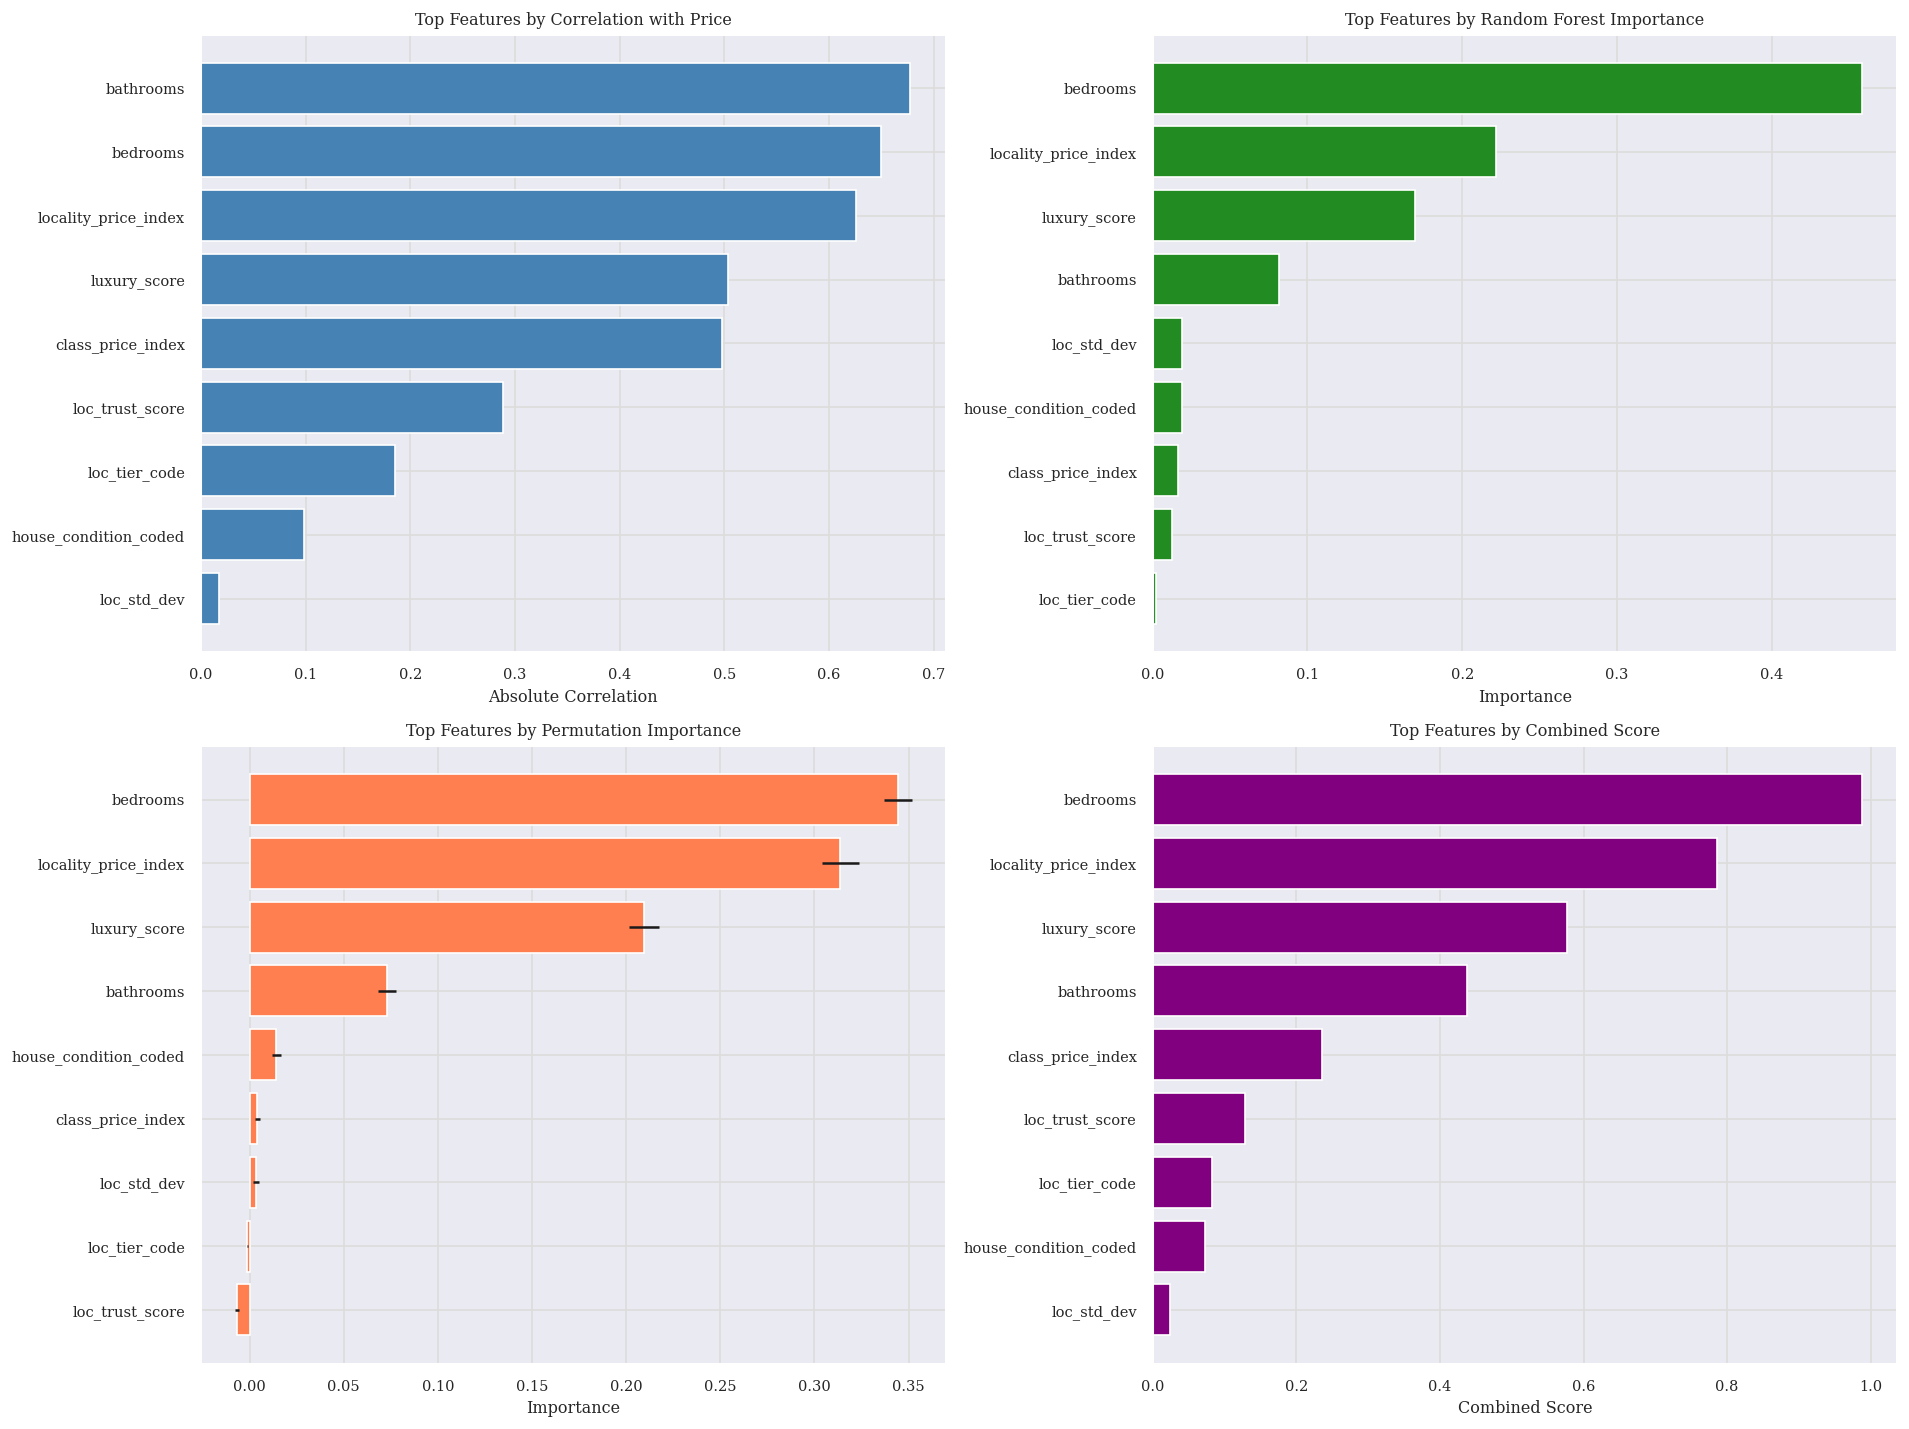

In [237]:
def plot_feature_importance(importance_results, top_n=15):
    """
    Visualize feature importance from different methods
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Plot 1: Correlation
    corr_data = importance_results["correlation"].head(top_n)
    axes[0, 0].barh(
        range(len(corr_data)), corr_data["abs_correlation"], color="steelblue"
    )
    axes[0, 0].set_yticks(range(len(corr_data)))
    axes[0, 0].set_yticklabels(corr_data.index)
    axes[0, 0].set_xlabel("Absolute Correlation")
    axes[0, 0].set_title("Top Features by Correlation with Price")
    axes[0, 0].invert_yaxis()

    # Plot 2: Random Forest
    rf_data = importance_results["random_forest"].head(top_n)
    axes[0, 1].barh(range(len(rf_data)), rf_data["importance"], color="forestgreen")
    axes[0, 1].set_yticks(range(len(rf_data)))
    axes[0, 1].set_yticklabels(rf_data["feature"])
    axes[0, 1].set_xlabel("Importance")
    axes[0, 1].set_title("Top Features by Random Forest Importance")
    axes[0, 1].invert_yaxis()

    # Plot 3: Permutation
    perm_data = importance_results["permutation"].head(top_n)
    axes[1, 0].barh(
        range(len(perm_data)),
        perm_data["importance"],
        xerr=perm_data["std"],
        color="coral",
    )
    axes[1, 0].set_yticks(range(len(perm_data)))
    axes[1, 0].set_yticklabels(perm_data["feature"])
    axes[1, 0].set_xlabel("Importance")
    axes[1, 0].set_title("Top Features by Permutation Importance")
    axes[1, 0].invert_yaxis()

    # Plot 4: Combined
    combined_data = importance_results["combined"].head(top_n)
    axes[1, 1].barh(
        range(len(combined_data)), combined_data["combined_score"], color="purple"
    )
    axes[1, 1].set_yticks(range(len(combined_data)))
    axes[1, 1].set_yticklabels(combined_data.index)
    axes[1, 1].set_xlabel("Combined Score")
    axes[1, 1].set_title("Top Features by Combined Score")
    axes[1, 1].invert_yaxis()

    plt.tight_layout()
    plt.show()


# Visualize
plot_feature_importance(importance_results, top_n=15)


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Load your current training data
# Replace with your actual path, e.g., self.train or pd.read_csv(...)
df = pd.read_csv("../artifacts/feature_engineering/features_train.csv")

# 2. Ensure log_price exists


# 5. Save the diagnostic plo

In [3]:
print(df["unit_density"].unique())
print(df["unit_density"].value_counts())


['multi_unit' 'single_unit' 'shared']
unit_density
multi_unit     7481
single_unit    4775
shared          204
Name: count, dtype: int64


/tmp/ipykernel_161276/1968021308.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


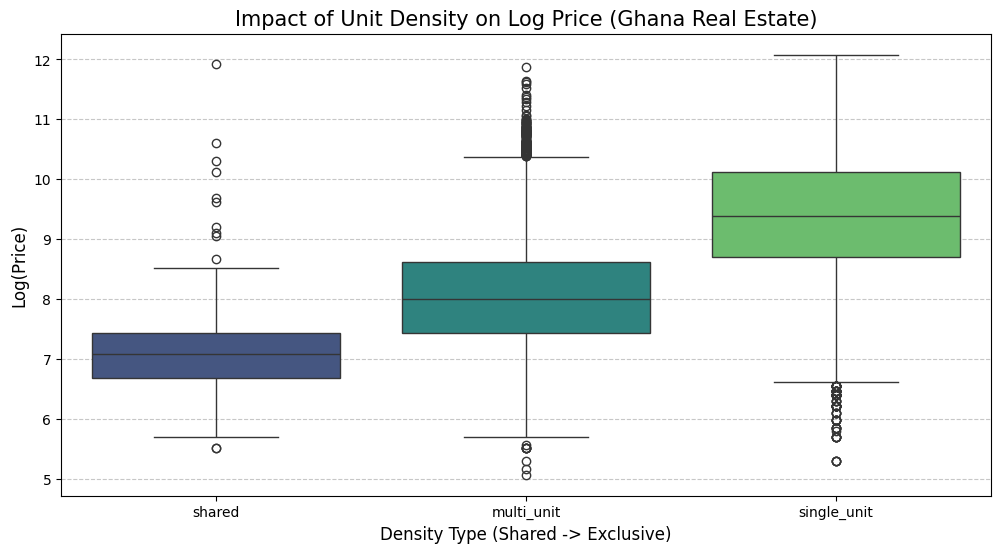

In [4]:
if "log_price" not in df.columns:
    df["log_price"] = np.log1p(df["price"])

# 3. Create the plot
plt.figure(figsize=(12, 6))
sns.boxplot(
    x="unit_density",
    y="log_price",
    data=df,
    order=["shared", "multi_unit", "single_unit"],  # Order by density hierarchy
    palette="viridis",
)

# 4. Add labels and aesthetics
plt.title("Impact of Unit Density on Log Price (Ghana Real Estate)", fontsize=15)
plt.xlabel("Density Type (Shared -> Exclusive)", fontsize=12)
plt.ylabel("Log(Price)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
